In [2]:
from components.broadcast_components.WZ_models.WZQuantizerWithDataPrep import _get_vec_slices, get_normalization_factor
import pickle
from typing import OrderedDict
from components.broadcast_components.broadcasting_process.ServerTrainingPerRoundProtocol import dict_to_array
import numpy as np
from matplotlib import pyplot as plt
import gzip

path_to_file = f'exp_data/save_grads_per_round/grad_round_{2}_worker_{0}.pkl.gz'
with gzip.open(path_to_file, 'rb') as f:
    y_dict= OrderedDict({k:v.cpu() for k,v in pickle.load(f).items()})
y_vec, shape_dict = dict_to_array(y_dict)

y_norm=y_vec.copy()
vec_slices = _get_vec_slices(shape_dict)
norm_factors = [get_normalization_factor(y_norm[v_slc]) for v_slc in vec_slices]
for i, temp in enumerate(vec_slices):
    y_norm[temp] /= norm_factors[i]

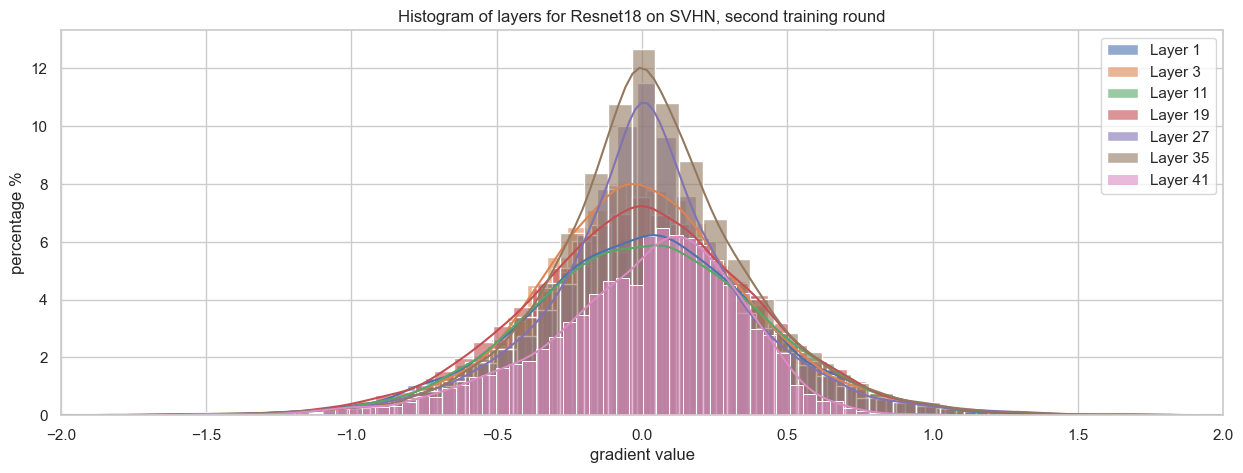

In [13]:
import seaborn as sns
sns.set(style="whitegrid")

plt.figure(figsize=(15, 5))

v_slc=vec_slices[0]
temp = np.random.choice(y_norm[v_slc], size=min(20_000, len(y_norm[v_slc])), replace=False)
sns.histplot(temp, bins=60, alpha=0.6, label=f'Layer {1}', kde=True, stat='percent')

for i in range(2, len(vec_slices), 8):
    v_slc=vec_slices[i]
    temp = np.random.choice(y_norm[v_slc], size=min(20_000, len(y_norm[v_slc])), replace=False)
    sns.histplot(temp, bins=60, alpha=0.6, label=f'Layer {i+1}', kde=True, stat='percent')
    
v_slc=vec_slices[-1]
temp = np.random.choice(y_norm[v_slc], size=min(20_000, len(y_norm[v_slc])), replace=False)
sns.histplot(temp, bins=60, alpha=0.6, label=f'Layer {len(vec_slices)}', kde=True, stat='percent')

plt.title(f'Histogram of layers for Resnet18 on SVHN, second training round')
plt.xlabel('gradient value')
plt.ylabel('percentage %')
plt.xlim(-2, 2)
plt.legend()
plt.grid(True)
plt.show()